In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path("../data/processed")
FIXTURES_DIR = PROCESSED_DIR / "fixtures"
METADATA_DIR = PROCESSED_DIR / "metadata"
LIVERPOOL_ID = 8
SEASON_LABELS = {21646: "Klopp 23-24", 23614: "Slot Y1 24-25", 25583: "Slot Y2 25-26"}
SEASON_SHORT = {21646: "Klopp", 23614: "Y1", 25583: "Y2"}
SEASON_IDS = [21646, 23614, 25583]
SEASON_COLORS = {21646: "#C8102E", 23614: "#00B2A9", 25583: "#F6C200"}
STATE_COLORS = {"WIN": "#2E7D32", "DRAW": "#F57C00", "LOSS": "#C62828"}
STATE_ORDER = ["WIN", "DRAW", "LOSS"]
FIG_DPI = 120
from liverpool_strategy.analysis.game_state import get_lfc_is_home, reconstruct_game_states, get_state_at_minute, final_score


## Deep Dive 1.4 — Game-State Tactical Shifts

**Question**: How does Liverpool's in-game behaviour change based on whether they are winning, drawing, or losing — and has this changed across the three seasons?

**Method**:
1. Reconstruct minute-by-minute game state (WIN / DRAW / LOSS) from goal events in `events.csv`.
   - `scores.csv` only has period totals — `events.csv` is the correct source.
   - Goal events are identified by a non-null `result` field (e.g. `"1-0"`, `"1-1"`).
   - Which team scored is inferred from the result delta + Liverpool's home/away status (from `fixture_season_mapping.csv`).
2. Tag each `ball_coordinates.csv` row with the game state at that estimated minute.
3. Analyse territorial patterns (ball x-distribution) by game state and season.

**Framing**:
- Klopp vs Slot comparisons → **confirmatory** (Bonferroni-corrected)
- Y1 vs Y2 comparisons → **exploratory** (effect sizes + directional signals; Y2 is a partial season)

**Key limitation on ball coordinates**: The x-coordinate in `ball_coordinates.csv` is absolute (0 = one end, 1 = other end) with no normalisation for which direction Liverpool is attacking. Patterns in x-distribution by game state are therefore interpreted as aggregate signals across all fixtures rather than Liverpool-specific attacking direction.

---

In [2]:
fixture_map = pd.read_csv(METADATA_DIR / "fixture_season_mapping.csv")
processed = fixture_map[fixture_map["has_processed_data"] == True].copy()

# NOTE: fixture_season_mapping home_team_id is unreliable for some fixtures.
# Derive lfc_is_home from scores.csv participant field — the authoritative source.
processed["lfc_is_home"] = processed["fixture_id"].apply(lambda fid: get_lfc_is_home(fid, FIXTURES_DIR, LIVERPOOL_ID))
processed = processed.dropna(subset=["lfc_is_home"]).copy()
processed["lfc_is_home"] = processed["lfc_is_home"].astype(bool)

season_counts = processed.groupby("season_id")["fixture_id"].count()
print(f"Fixtures with processed data: {len(processed)}")
for sid in SEASON_IDS:
    n = season_counts.get(sid, 0)
    home = processed[(processed["season_id"] == sid) & (processed["lfc_is_home"] == True)].shape[0]
    print(f"  {SEASON_LABELS[sid]}: {n} fixtures ({home} home, {n - home} away)")


Fixtures with processed data: 101
  Klopp 23-24: 37 fixtures (18 home, 19 away)
  Slot Y1 24-25: 34 fixtures (17 home, 17 away)
  Slot Y2 25-26: 30 fixtures (14 home, 16 away)


### Part 1 — Game State Reconstruction

For each fixture, goal events are extracted from `events.csv`, sorted by effective minute (`minute + extra_minute`), and used to build a timeline of Liverpool's game state.

Before any goals the state is `DRAW` (0-0). Each goal shifts the state based on who scored (inferred from the result delta and Liverpool's home/away position).

In [3]:
# Build game state intervals for all fixtures
fixture_states = {}  # fixture_id -> dict with intervals + metadata

for _, row in processed.iterrows():
    fid = int(row["fixture_id"])
    events_path = FIXTURES_DIR / str(fid) / "events.csv"
    if not events_path.exists():
        continue

    events_df = pd.read_csv(events_path)
    intervals = reconstruct_game_states(events_df, row["lfc_is_home"])

    lfc_g, opp_g = final_score(intervals)
    if lfc_g > opp_g:
        result = "W"
    elif lfc_g < opp_g:
        result = "L"
    else:
        result = "D"

    fixture_states[fid] = {
        "intervals": intervals,
        "season_id": int(row["season_id"]),
        "season": row["season"],
        "manager": row["manager"],
        "lfc_is_home": row["lfc_is_home"],
        "lfc_goals": lfc_g,
        "opp_goals": opp_g,
        "result": result,
        "n_goals": lfc_g + opp_g,
    }

print(f"Game states built for {len(fixture_states)} fixtures")

Game states built for 101 fixtures


#### Validation: reconstructed scores vs `scores.csv`

Cross-check the reconstructed final score against `scores.csv` (CURRENT period totals).

In [4]:
mismatches = []
scores_checked = 0

for fid, meta in fixture_states.items():
    scores_path = FIXTURES_DIR / str(fid) / "scores.csv"
    if not scores_path.exists():
        continue

    sc = pd.read_csv(scores_path)
    # type_id 1525 = CURRENT (full-time); sum per participant
    current = sc[sc["description"] == "CURRENT"]
    if current.empty:
        # Fallback: sum all period goals for Liverpool
        lfc_sc = sc[sc["participant_id"] == LIVERPOOL_ID]["goals"].sum()
    else:
        lfc_row = current[current["participant_id"] == LIVERPOOL_ID]
        lfc_sc = int(lfc_row["goals"].iloc[0]) if not lfc_row.empty else None

    if lfc_sc is not None:
        scores_checked += 1
        if lfc_sc != meta["lfc_goals"]:
            mismatches.append({
                "fixture_id": fid,
                "reconstructed_lfc": meta["lfc_goals"],
                "scores_csv_lfc": lfc_sc,
                "season": meta["season"],
            })

print(f"Validated {scores_checked} fixtures against scores.csv")
print(f"Mismatches: {len(mismatches)}")
if mismatches:
    print(pd.DataFrame(mismatches).to_string(index=False))

Validated 101 fixtures against scores.csv
Mismatches: 0


---
### Part 2 — Win / Draw / Loss Record by Season

Before analysing game states, establish the match outcome distribution. This sets the context: the results regression (2.12 → 1.68 PPG) seen in the statistical comparison.

In [5]:
# Build per-fixture summary table
records = []
for fid, meta in fixture_states.items():
    records.append({
        "fixture_id": fid,
        "season_id": meta["season_id"],
        "season": meta["season"],
        "result": meta["result"],
        "lfc_goals": meta["lfc_goals"],
        "opp_goals": meta["opp_goals"],
        "n_goals": meta["n_goals"],
        "lfc_is_home": meta["lfc_is_home"],
    })

results_df = pd.DataFrame(records)

# Season summary
summary = []
for sid in SEASON_IDS:
    sub = results_df[results_df["season_id"] == sid]
    n = len(sub)
    wins = (sub["result"] == "W").sum()
    draws = (sub["result"] == "D").sum()
    losses = (sub["result"] == "L").sum()
    gf = sub["lfc_goals"].sum()
    ga = sub["opp_goals"].sum()
    pts = wins * 3 + draws
    ppg = pts / n if n > 0 else 0
    summary.append({
        "Season": SEASON_LABELS[sid],
        "Games": n,
        "W": wins, "D": draws, "L": losses,
        "GF": gf, "GA": ga, "GD": gf - ga,
        "Pts": pts, "PPG": round(ppg, 2),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

       Season  Games  W  D  L  GF  GA  GD  Pts  PPG
  Klopp 23-24     37 23 10  4  83  40  43   79 2.14
Slot Y1 24-25     34 21  9  4  78  40  38   72 2.12
Slot Y2 25-26     30 14  7  9  50  39  11   49 1.63


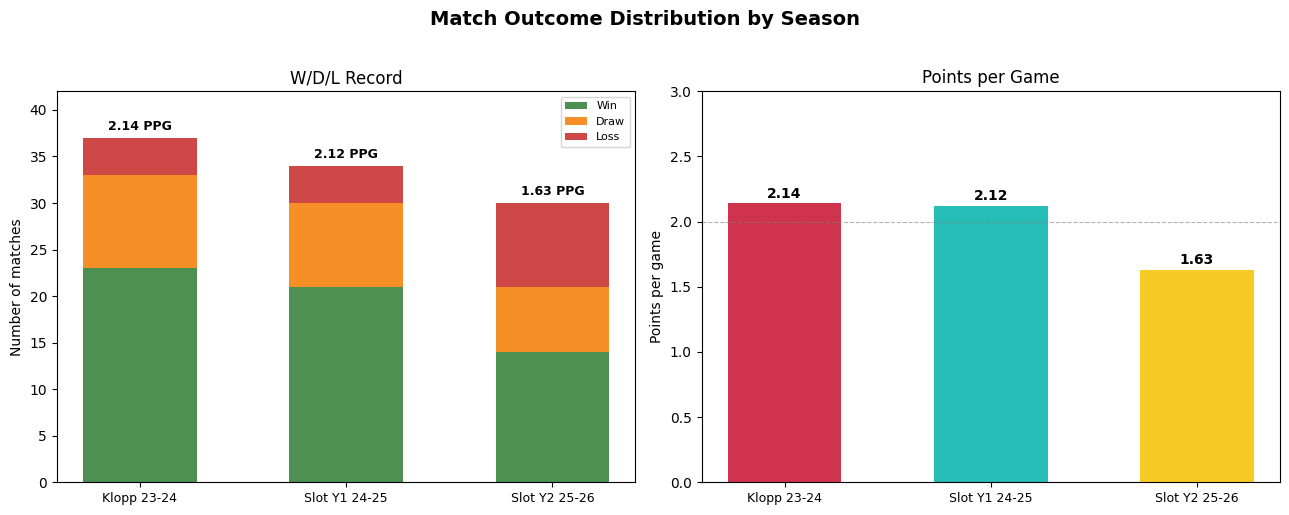

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Match Outcome Distribution by Season", fontsize=14, fontweight="bold", y=1.02)

# --- Left: stacked bar of W/D/L counts ---
ax = axes[0]
season_names = [SEASON_LABELS[sid] for sid in SEASON_IDS]
wins  = [summary_df.loc[summary_df["Season"] == SEASON_LABELS[sid], "W"].iloc[0] for sid in SEASON_IDS]
draws = [summary_df.loc[summary_df["Season"] == SEASON_LABELS[sid], "D"].iloc[0] for sid in SEASON_IDS]
losses= [summary_df.loc[summary_df["Season"] == SEASON_LABELS[sid], "L"].iloc[0] for sid in SEASON_IDS]

x = np.arange(len(SEASON_IDS))
w = 0.55
b1 = ax.bar(x, wins, w, label="Win",  color=STATE_COLORS["WIN"],  alpha=0.85)
b2 = ax.bar(x, draws, w, bottom=wins, label="Draw", color=STATE_COLORS["DRAW"], alpha=0.85)
b3 = ax.bar(x, losses, w, bottom=[wins[i] + draws[i] for i in range(3)],
            label="Loss", color=STATE_COLORS["LOSS"], alpha=0.85)

# PPG annotation
for i, sid in enumerate(SEASON_IDS):
    ppg = summary_df.loc[summary_df["Season"] == SEASON_LABELS[sid], "PPG"].iloc[0]
    total = wins[i] + draws[i] + losses[i]
    ax.text(i, total + 0.5, f"{ppg} PPG", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(season_names, fontsize=9)
ax.set_ylabel("Number of matches")
ax.set_title("W/D/L Record")
ax.legend(loc="upper right", fontsize=8)
ax.set_ylim(0, max([w + d + l for w, d, l in zip(wins, draws, losses)]) + 5)

# --- Right: Points per game trend ---
ax2 = axes[1]
ppg_vals = [summary_df.loc[summary_df["Season"] == SEASON_LABELS[sid], "PPG"].iloc[0] for sid in SEASON_IDS]
bars = ax2.bar(x, ppg_vals, w, color=[SEASON_COLORS[sid] for sid in SEASON_IDS], alpha=0.85)
for bar, ppg in zip(bars, ppg_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{ppg:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax2.set_xticks(x)
ax2.set_xticklabels(season_names, fontsize=9)
ax2.set_ylabel("Points per game")
ax2.set_title("Points per Game")
ax2.set_ylim(0, 3.0)
ax2.axhline(2.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.show()

---
### Part 3 — Lead Management: Blowing Leads and Coming From Behind

**Narrative question**: The results regression in Y2 — is it because Liverpool *blow leads they had in Y1*, or because they *trail more often*?

For each fixture, track **score transitions**:
- **Lead blown**: Liverpool were ahead (WIN state), then conceded to equalise or fall behind
- **Comeback**: Liverpool were behind (LOSS state), then scored to level or go ahead
- **Clean sheet from lead**: Liverpool held a lead to the end (lead held)

In [7]:
transition_records = []

for fid, meta in fixture_states.items():
    intervals = meta["intervals"]
    sid = meta["season_id"]

    states_seq = [s for (_, _, _, s) in intervals]

    # Detect transitions
    ever_led = any(s == "WIN" for s in states_seq)
    ever_trailed = any(s == "LOSS" for s in states_seq)

    lead_blown = False
    comeback = False
    for i in range(1, len(states_seq)):
        if states_seq[i - 1] == "WIN" and states_seq[i] in ("DRAW", "LOSS"):
            lead_blown = True  # at any point during match, not necessarily at full time
        if states_seq[i - 1] == "LOSS" and states_seq[i] in ("DRAW", "WIN"):
            comeback = True

    final_state = states_seq[-1]
    # lead_held = won the match (independent of whether lead was temporarily lost)
    lead_held = (ever_led and final_state == "WIN")
    # lead_blown_perm = went ahead then finished NOT winning (lead not recovered)
    lead_blown_perm = (ever_led and final_state != "WIN" and lead_blown)

    # Minutes spent in each state: use actual match duration from ball coordinates
    # to correctly handle ET (e.g. goals at 90+5' are missed if we cap at 90)
    bc_path = FIXTURES_DIR / str(fid) / "ball_coordinates.csv"
    if bc_path.exists():
        bc_meta = pd.read_csv(bc_path, usecols=["estimated_minute"]).dropna()
        match_duration = int(np.ceil(bc_meta["estimated_minute"].max())) if len(bc_meta) > 0 else 90
    else:
        match_duration = 90

    minutes_in_state = {"WIN": 0, "DRAW": 0, "LOSS": 0}
    for i, (m, _lg, _og, s) in enumerate(intervals):
        end = intervals[i + 1][0] if i + 1 < len(intervals) else match_duration
        end = min(end, match_duration)
        start = min(m, match_duration)
        duration = max(0, end - start)
        minutes_in_state[s] = minutes_in_state.get(s, 0) + duration

    total_minutes = sum(minutes_in_state.values()) or match_duration

    transition_records.append({
        "fixture_id": fid,
        "season_id": sid,
        "season": meta["season"],
        "result": meta["result"],
        "match_duration": match_duration,
        "ever_led": ever_led,
        "ever_trailed": ever_trailed,
        "lead_blown": lead_blown,
        "comeback": comeback,
        "lead_held": lead_held,
        "lead_blown_perm": lead_blown_perm,  # led, then trailed or drew at full time
        "minutes_win": minutes_in_state["WIN"],
        "minutes_draw": minutes_in_state["DRAW"],
        "minutes_loss": minutes_in_state["LOSS"],
        "pct_win": minutes_in_state["WIN"] / total_minutes,
        "pct_draw": minutes_in_state["DRAW"] / total_minutes,
        "pct_loss": minutes_in_state["LOSS"] / total_minutes,
    })

trans_df = pd.DataFrame(transition_records)

# Per-season summary
lead_summary = []
for sid in SEASON_IDS:
    sub = trans_df[trans_df["season_id"] == sid]
    n = len(sub)
    lead_summary.append({
        "Season": SEASON_SHORT[sid],
        "Games": n,
        "Ever Led": f"{sub['ever_led'].sum()} ({sub['ever_led'].mean():.0%})",
        "Lead Held (won)": f"{sub['lead_held'].sum()} ({sub['lead_held'].mean():.0%})",
        "Lead Blown (temp)": f"{sub['lead_blown'].sum()} ({sub['lead_blown'].mean():.0%}) — at any point in match",
        "Ever Trailed": f"{sub['ever_trailed'].sum()} ({sub['ever_trailed'].mean():.0%})",
        "Comeback": f"{sub['comeback'].sum()} ({sub['comeback'].mean():.0%})",
        "Avg % Winning": f"{sub['pct_win'].mean():.1%}",
        "Avg % Drawing": f"{sub['pct_draw'].mean():.1%}",
        "Avg % Losing": f"{sub['pct_loss'].mean():.1%}",
    })

lead_df = pd.DataFrame(lead_summary)
print(lead_df.T.to_string())


                                                  0                                 1                                2
Season                                        Klopp                                Y1                               Y2
Games                                            37                                34                               30
Ever Led                                   28 (76%)                          28 (82%)                         19 (63%)
Lead Held (won)                            23 (62%)                          21 (62%)                         14 (47%)
Lead Blown (temp)  11 (30%) — at any point in match  11 (32%) — at any point in match  7 (23%) — at any point in match
Ever Trailed                               17 (46%)                          17 (50%)                         12 (40%)
Comeback                                   15 (41%)                          13 (38%)                          9 (30%)
Avg % Winning                                 36

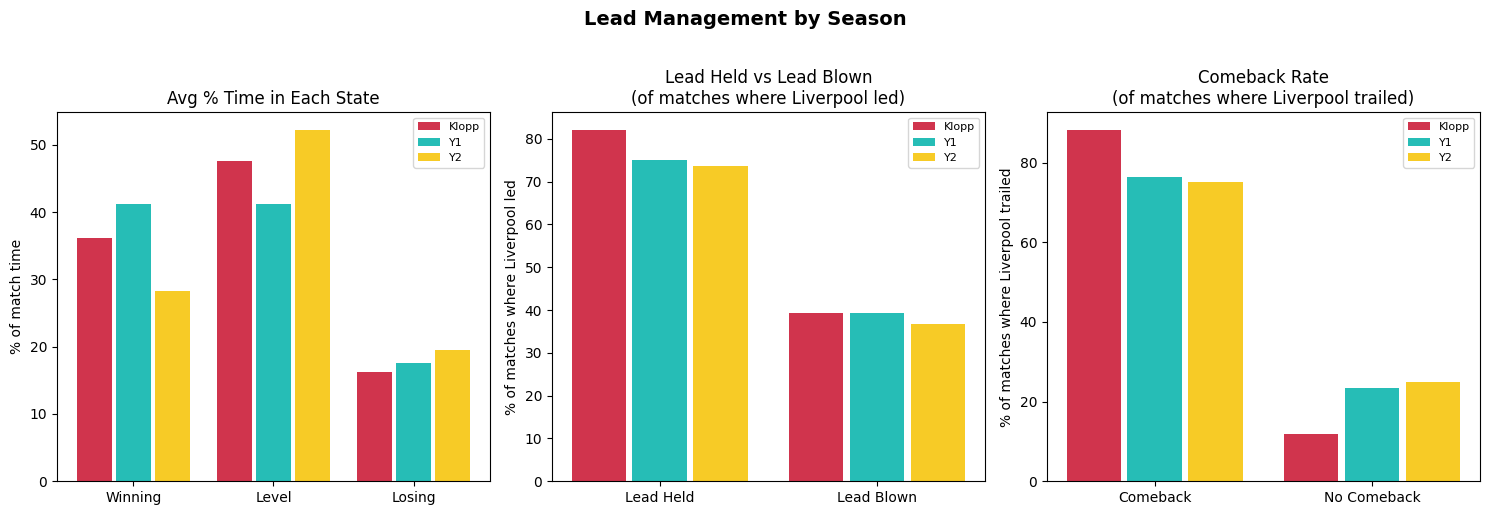

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Lead Management by Season", fontsize=14, fontweight="bold", y=1.02)

# ---- Plot 1: Average % of match time in each game state ----
ax = axes[0]
for i, sid in enumerate(SEASON_IDS):
    sub = trans_df[trans_df["season_id"] == sid]
    means = [sub["pct_win"].mean(), sub["pct_draw"].mean(), sub["pct_loss"].mean()]
    x = np.arange(3) + i * 0.28 - 0.28
    bars = ax.bar(x, [m * 100 for m in means], 0.25,
                  color=SEASON_COLORS[sid], alpha=0.85,
                  label=SEASON_SHORT[sid])

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Winning", "Level", "Losing"])
ax.set_ylabel("% of match time")
ax.set_title("Avg % Time in Each State")
ax.legend(fontsize=8)

# ---- Plot 2: Lead held vs blown (of matches where Liverpool ever led) ----
ax2 = axes[1]
categories = ["Lead Held", "Lead Blown"]
for i, sid in enumerate(SEASON_IDS):
    sub = trans_df[trans_df["season_id"] == sid]
    ever_led = sub[sub["ever_led"]]
    if len(ever_led) == 0:
        continue
    held_pct = ever_led["lead_held"].mean() * 100
    blown_pct = ever_led["lead_blown"].mean() * 100
    x = np.arange(2) + i * 0.28 - 0.28
    ax2.bar(x, [held_pct, blown_pct], 0.25,
            color=SEASON_COLORS[sid], alpha=0.85, label=SEASON_SHORT[sid])

ax2.set_xticks([0, 1])
ax2.set_xticklabels(categories)
ax2.set_ylabel("% of matches where Liverpool led")
ax2.set_title("Lead Held vs Lead Blown\n(of matches where Liverpool led)")
ax2.legend(fontsize=8)

# ---- Plot 3: Comeback rate (of matches where Liverpool trailed) ----
ax3 = axes[2]
for i, sid in enumerate(SEASON_IDS):
    sub = trans_df[trans_df["season_id"] == sid]
    ever_trailed = sub[sub["ever_trailed"]]
    if len(ever_trailed) == 0:
        continue
    comeback_pct = ever_trailed["comeback"].mean() * 100
    no_comeback_pct = 100 - comeback_pct
    x = np.arange(2) + i * 0.28 - 0.28
    ax3.bar(x, [comeback_pct, no_comeback_pct], 0.25,
            color=SEASON_COLORS[sid], alpha=0.85, label=SEASON_SHORT[sid])

ax3.set_xticks([0, 1])
ax3.set_xticklabels(["Comeback", "No Comeback"])
ax3.set_ylabel("% of matches where Liverpool trailed")
ax3.set_title("Comeback Rate\n(of matches where Liverpool trailed)")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
# Statistical tests: % time winning per match, Klopp vs Slot Y2 (confirmatory) and Y1 vs Y2 (exploratory)
# Bonferroni note: α/44 is used as a conservative project-wide threshold for all Klopp vs Slot
# confirmatory comparisons (consistent with notebook 01's test family). These 3 tests were NOT
# part of the original 44 stat-type comparisons — using α/44 here is deliberately conservative.
# If treating this notebook's 3 confirmatory tests as an independent family, α/3 = 0.017 applies.
print("=" * 65)
print("STATISTICAL TESTS — % of match time in WIN state")
print("=" * 65)

klopp_win = trans_df[trans_df["season_id"] == 21646]["pct_win"].values
y1_win    = trans_df[trans_df["season_id"] == 23614]["pct_win"].values
y2_win    = trans_df[trans_df["season_id"] == 25583]["pct_win"].values

# Klopp vs Y2 (confirmatory: conservative threshold α/44 = 0.00114 for project-wide consistency)
t, p = stats.ttest_ind(klopp_win, y2_win, equal_var=False)
d = (np.mean(klopp_win) - np.mean(y2_win)) / np.sqrt(
    (np.std(klopp_win, ddof=1)**2 + np.std(y2_win, ddof=1)**2) / 2
)
print(f"\n[CONFIRMATORY] Klopp vs Slot Y2 — % time winning")
print(f"  Klopp: {np.mean(klopp_win):.1%} ± {np.std(klopp_win, ddof=1):.1%}")
print(f"  Slot Y2: {np.mean(y2_win):.1%} ± {np.std(y2_win, ddof=1):.1%}")
print(f"  Welch t={t:.3f}, p={p:.4f}, d={d:.2f}")
print(f"  Conservative threshold (α/44=0.00114): {'SIGNIFICANT ✅' if p < 0.00114 else 'not significant'}")
print(f"  Notebook-family threshold (α/3=0.017):  {'SIGNIFICANT ✅' if p < 0.017 else 'not significant'}")

# Y1 vs Y2 (exploratory: nominal p < 0.05 worth flagging)
t2, p2 = stats.ttest_ind(y1_win, y2_win, equal_var=False)
d2 = (np.mean(y1_win) - np.mean(y2_win)) / np.sqrt(
    (np.std(y1_win, ddof=1)**2 + np.std(y2_win, ddof=1)**2) / 2
)
print(f"\n[EXPLORATORY] Slot Y1 vs Slot Y2 — % time winning")
print(f"  Slot Y1: {np.mean(y1_win):.1%} ± {np.std(y1_win, ddof=1):.1%}")
print(f"  Slot Y2: {np.mean(y2_win):.1%} ± {np.std(y2_win, ddof=1):.1%}")
print(f"  Welch t={t2:.3f}, p={p2:.4f}, d={d2:.2f}")
print(f"  Nominal p < 0.05 → {'directional signal ⚠️' if p2 < 0.05 else 'no signal'}")

print("\n--- % time losing ---")
klopp_loss = trans_df[trans_df["season_id"] == 21646]["pct_loss"].values
y1_loss    = trans_df[trans_df["season_id"] == 23614]["pct_loss"].values
y2_loss    = trans_df[trans_df["season_id"] == 25583]["pct_loss"].values

t3, p3 = stats.ttest_ind(klopp_loss, y2_loss, equal_var=False)
d3 = (np.mean(y2_loss) - np.mean(klopp_loss)) / np.sqrt(
    (np.std(klopp_loss, ddof=1)**2 + np.std(y2_loss, ddof=1)**2) / 2
)
print(f"\n[CONFIRMATORY] Klopp vs Slot Y2 — % time losing")
print(f"  Klopp: {np.mean(klopp_loss):.1%} ± {np.std(klopp_loss, ddof=1):.1%}")
print(f"  Slot Y2: {np.mean(y2_loss):.1%} ± {np.std(y2_loss, ddof=1):.1%}")
print(f"  Welch t={t3:.3f}, p={p3:.4f}, d={d3:.2f}")
print(f"  Conservative threshold (α/44=0.00114): {'SIGNIFICANT ✅' if p3 < 0.00114 else 'not significant'}")
print(f"  Notebook-family threshold (α/3=0.017):  {'SIGNIFICANT ✅' if p3 < 0.017 else 'not significant'}")


STATISTICAL TESTS — % of match time in WIN state

[CONFIRMATORY] Klopp vs Slot Y2 — % time winning
  Klopp: 36.2% ± 31.1%
  Slot Y2: 28.2% ± 32.4%
  Welch t=1.019, p=0.3121, d=0.25
  Conservative threshold (α/44=0.00114): not significant
  Notebook-family threshold (α/3=0.017):  not significant

[EXPLORATORY] Slot Y1 vs Slot Y2 — % time winning
  Slot Y1: 41.1% ± 32.0%
  Slot Y2: 28.2% ± 32.4%
  Welch t=1.601, p=0.1146, d=0.40
  Nominal p < 0.05 → no signal

--- % time losing ---

[CONFIRMATORY] Klopp vs Slot Y2 — % time losing
  Klopp: 16.2% ± 23.9%
  Slot Y2: 19.5% ± 31.6%
  Welch t=-0.483, p=0.6308, d=0.12
  Conservative threshold (α/44=0.00114): not significant
  Notebook-family threshold (α/3=0.017):  not significant


---
### Part 4 — Goals by Game State: When Does Liverpool Score and Concede?

Break down goals **scored** and **conceded** by the game state *at the time of the goal*.

- **Goal scored from DRAW**: Liverpool take the lead from level (0-0 or 1-1)
- **Goal scored from WIN**: Liverpool extend a lead
- **Goal scored from LOSS**: Liverpool pull one back
- **Goal conceded from WIN**: Liverpool *lose a lead* — the highest-cost event
- **Goal conceded from DRAW**: Opponent takes the lead
- **Goal conceded from LOSS**: Opponent extends their lead

In [10]:
goal_state_records = []

for fid, meta in fixture_states.items():
    intervals = meta["intervals"]
    sid = meta["season_id"]

    # Each interval transition = a goal (except the first, which is 0-0 start)
    for i in range(1, len(intervals)):
        prev_min, prev_lfc, prev_opp, prev_state = intervals[i - 1]
        curr_min, curr_lfc, curr_opp, curr_state = intervals[i]

        # Determine who scored
        if curr_lfc > prev_lfc:
            scorer = "liverpool"
        elif curr_opp > prev_opp:
            scorer = "opponent"
        else:
            scorer = "unknown"

        goal_state_records.append({
            "fixture_id": fid,
            "season_id": sid,
            "season": meta["season"],
            "minute": curr_min,
            "scorer": scorer,
            "state_before": prev_state,
            "state_after": curr_state,
        })

goals_by_state_df = pd.DataFrame(goal_state_records)

print(f"Total goal events: {len(goals_by_state_df)}")
print(f"Liverpool goals: {(goals_by_state_df['scorer'] == 'liverpool').sum()}")
print(f"Opponent goals: {(goals_by_state_df['scorer'] == 'opponent').sum()}")

Total goal events: 330
Liverpool goals: 211
Opponent goals: 119


In [11]:
# Pivot: goals scored/conceded by state_before and season
for scorer_type, label in [("liverpool", "Goals SCORED by Liverpool"), ("opponent", "Goals CONCEDED by Liverpool")]:
    sub = goals_by_state_df[goals_by_state_df["scorer"] == scorer_type]
    pivot = sub.groupby(["season_id", "state_before"]).size().unstack(fill_value=0)
    pivot.index = [SEASON_SHORT[sid] for sid in pivot.index]
    print(f"\n{label} (by game state at time of goal):")
    # Reorder columns
    cols = [c for c in STATE_ORDER if c in pivot.columns]
    print(pivot[cols].to_string())

    # Per-match averages
    counts = trans_df.groupby("season_id")["fixture_id"].count()
    print(f"  (per match averages:)")
    for sid in SEASON_IDS:
        n = counts.get(sid, 1)
        sname = SEASON_SHORT[sid]
        if sname in pivot.index:
            row = pivot.loc[sname, cols]
            per_match = (row / n).round(2)
            print(f"    {sname}: " + " | ".join([f"{c}={v:.2f}" for c, v in zip(cols, per_match)]))


Goals SCORED by Liverpool (by game state at time of goal):
state_before  WIN  DRAW  LOSS
Klopp          32    36    15
Y1             27    33    18
Y2             16    22    12
  (per match averages:)
    Klopp: WIN=0.86 | DRAW=0.97 | LOSS=0.41
    Y1: WIN=0.79 | DRAW=0.97 | LOSS=0.53
    Y2: WIN=0.53 | DRAW=0.73 | LOSS=0.40

Goals CONCEDED by Liverpool (by game state at time of goal):
state_before  WIN  DRAW  LOSS
Klopp          19    19     2
Y1             17    20     3
Y2             16    18     5
  (per match averages:)
    Klopp: WIN=0.51 | DRAW=0.51 | LOSS=0.05
    Y1: WIN=0.50 | DRAW=0.59 | LOSS=0.09
    Y2: WIN=0.53 | DRAW=0.60 | LOSS=0.17


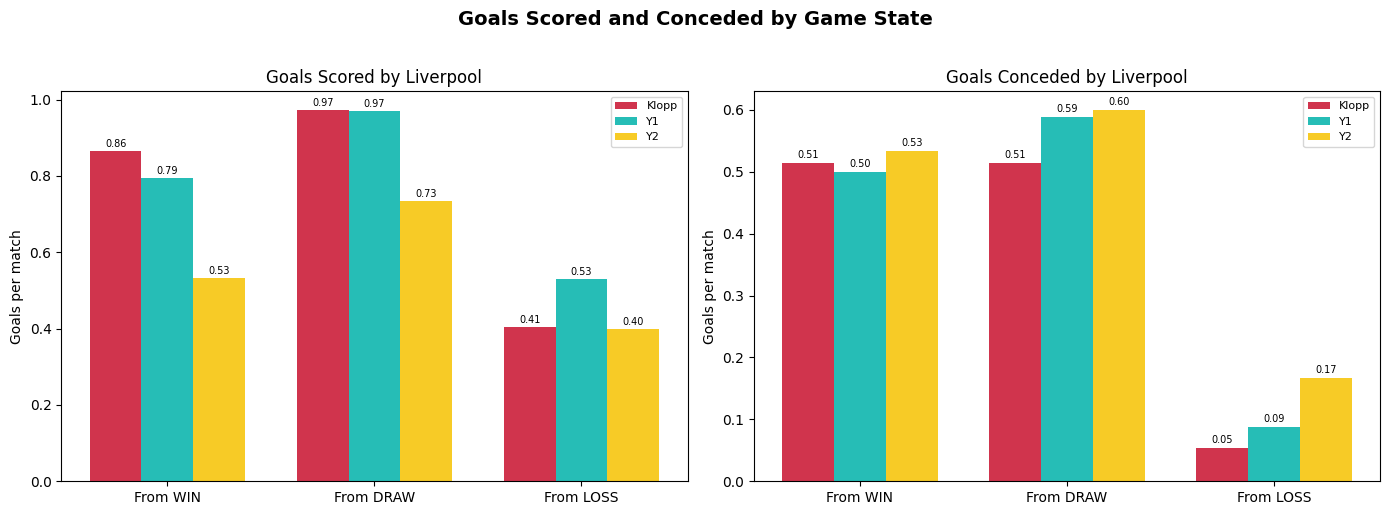

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Goals Scored and Conceded by Game State", fontsize=14, fontweight="bold", y=1.02)

for ax_idx, (scorer_type, title) in enumerate([
    ("liverpool", "Goals Scored by Liverpool"),
    ("opponent",  "Goals Conceded by Liverpool"),
]):
    ax = axes[ax_idx]
    sub = goals_by_state_df[goals_by_state_df["scorer"] == scorer_type]

    # Per-match rate by state and season
    plot_data = []
    for sid in SEASON_IDS:
        n = trans_df[trans_df["season_id"] == sid]["fixture_id"].count()
        for state in STATE_ORDER:
            count = sub[(sub["season_id"] == sid) & (sub["state_before"] == state)].shape[0]
            plot_data.append({
                "season_id": sid,
                "state": state,
                "per_match": count / n if n > 0 else 0,
            })

    plot_df = pd.DataFrame(plot_data)

    x = np.arange(len(STATE_ORDER))
    width = 0.25
    for i, sid in enumerate(SEASON_IDS):
        vals = [plot_df[(plot_df["season_id"] == sid) & (plot_df["state"] == s)]["per_match"].iloc[0]
                for s in STATE_ORDER]
        bars = ax.bar(x + (i - 1) * width, vals, width,
                      color=SEASON_COLORS[sid], alpha=0.85, label=SEASON_SHORT[sid])
        for bar, v in zip(bars, vals):
            if v > 0.02:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                        f"{v:.2f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([f"From {s}" for s in STATE_ORDER])
    ax.set_ylabel("Goals per match")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
### Part 5 — Ball Territory by Game State

Tag each `ball_coordinates.csv` row with Liverpool's game state at that estimated minute, then compare the ball's x-distribution by game state and season.

**Caveat on x-coordinate interpretation**: The x-axis in `ball_coordinates.csv` is absolute (0 → 1) and does not normalise for which direction Liverpool are attacking. Teams swap ends at half-time, and Liverpool attacks toward different ends in home vs away games. The patterns below reflect *aggregate* signals across all fixtures. Shifts in the spread of x (variance, inter-quartile range) and relative changes between game states are more interpretable than absolute positional values.

In [13]:
# Load ball coordinates and tag with game state
# Only load columns we need to keep memory reasonable
coord_frames = []

for fid, meta in fixture_states.items():
    bc_path = FIXTURES_DIR / str(fid) / "ball_coordinates.csv"
    if not bc_path.exists():
        continue

    bc = pd.read_csv(bc_path, usecols=["fixture_id", "estimated_minute", "x", "y",
                                        "pitch_zone", "distance_to_goal"])
    bc = bc.dropna(subset=["estimated_minute", "x"])

    intervals = meta["intervals"]
    # Vectorised state lookup: build (minute, state) boundaries
    boundary_mins = [iv[0] for iv in intervals]
    boundary_states = [iv[3] for iv in intervals]

    def lookup_state(minute, b_mins=boundary_mins, b_states=boundary_states):
        idx = np.searchsorted(b_mins, minute, side='right') - 1
        idx = max(0, min(idx, len(b_states) - 1))
        return b_states[idx]

    bc["game_state"] = bc["estimated_minute"].apply(lookup_state)
    bc["season_id"] = meta["season_id"]
    bc["season"] = meta["season"]
    coord_frames.append(bc)

coords_df = pd.concat(coord_frames, ignore_index=True)
print(f"Ball coordinates loaded: {len(coords_df):,} rows")
print("\nGame state distribution:")
print(coords_df["game_state"].value_counts())
print("\nSeason × Game state counts:")
print(coords_df.groupby(["season_id", "game_state"]).size().unstack())

Ball coordinates loaded: 93,842 rows

Game state distribution:
game_state
DRAW    43170
WIN     34571
LOSS    16101
Name: count, dtype: int64

Season × Game state counts:
game_state   DRAW  LOSS    WIN
season_id                     
21646       15422  5178  14353
23614       12212  5379  12319
25583       15536  5544   7899


In [14]:
# Pitch zone distribution by game state and season
zone_order = ["defensive_third", "middle_third", "attacking_third"]

zone_summary = (
    coords_df
    .groupby(["season_id", "game_state", "pitch_zone"])
    .size()
    .reset_index(name="count")
)
zone_totals = coords_df.groupby(["season_id", "game_state"]).size().reset_index(name="total")
zone_summary = zone_summary.merge(zone_totals, on=["season_id", "game_state"])
zone_summary["pct"] = zone_summary["count"] / zone_summary["total"] * 100

# Focus: % in each zone when in WIN state (the main question)
print("Pitch zone % when Liverpool are WINNING:")
win_zones = zone_summary[zone_summary["game_state"] == "WIN"].copy()
win_pivot = win_zones.pivot_table(index="season_id", columns="pitch_zone", values="pct").reindex(SEASON_IDS)
win_pivot.index = [SEASON_SHORT[sid] for sid in SEASON_IDS]
print(win_pivot[[z for z in zone_order if z in win_pivot.columns]].round(1).to_string())

print("\nPitch zone % when Liverpool are DRAWING:")
draw_zones = zone_summary[zone_summary["game_state"] == "DRAW"].copy()
draw_pivot = draw_zones.pivot_table(index="season_id", columns="pitch_zone", values="pct").reindex(SEASON_IDS)
draw_pivot.index = [SEASON_SHORT[sid] for sid in SEASON_IDS]
print(draw_pivot[[z for z in zone_order if z in draw_pivot.columns]].round(1).to_string())

print("\nPitch zone % when Liverpool are LOSING:")
loss_zones = zone_summary[zone_summary["game_state"] == "LOSS"].copy()
loss_pivot = loss_zones.pivot_table(index="season_id", columns="pitch_zone", values="pct").reindex(SEASON_IDS)
loss_pivot.index = [SEASON_SHORT[sid] for sid in SEASON_IDS]
print(loss_pivot[[z for z in zone_order if z in loss_pivot.columns]].round(1).to_string())

Pitch zone % when Liverpool are WINNING:
pitch_zone  defensive_third  middle_third  attacking_third
Klopp                  25.5          40.0             34.5
Y1                     28.3          34.8             36.9
Y2                     29.1          38.2             32.7

Pitch zone % when Liverpool are DRAWING:
pitch_zone  defensive_third  middle_third  attacking_third
Klopp                  28.0          37.9             34.1
Y1                     34.1          36.6             29.3
Y2                     31.3          35.1             33.7

Pitch zone % when Liverpool are LOSING:
pitch_zone  defensive_third  middle_third  attacking_third
Klopp                  31.7          38.3             30.0
Y1                     26.8          38.6             34.6
Y2                     36.1          34.9             29.0


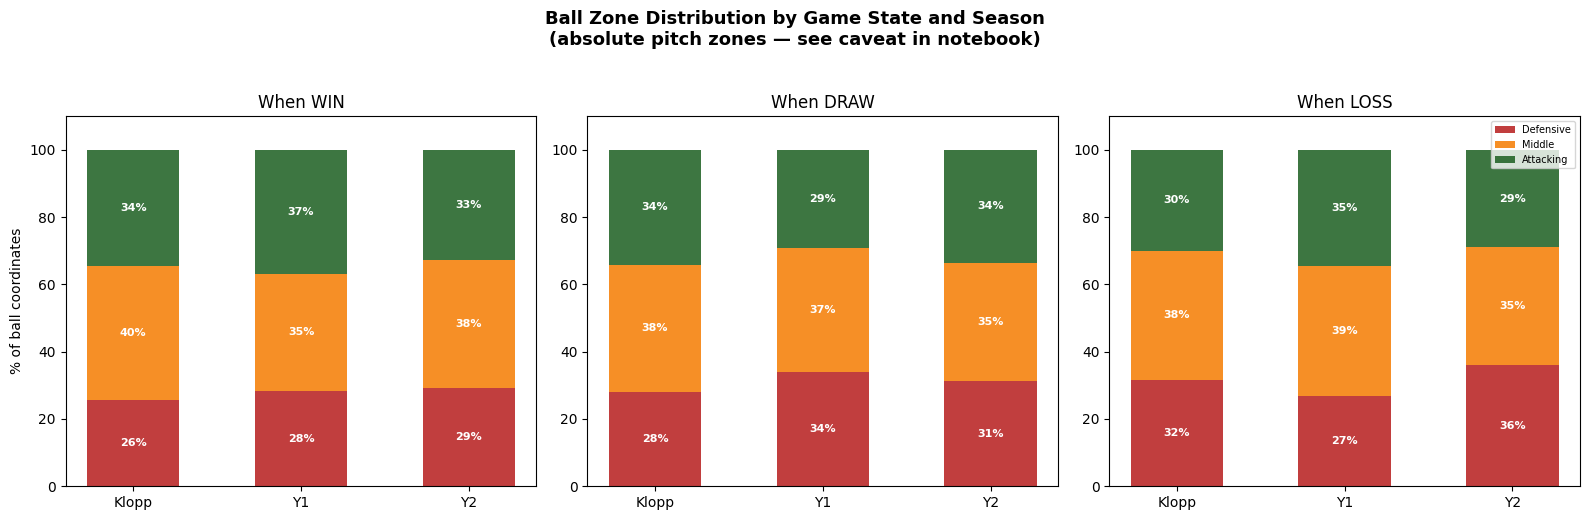

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Ball Zone Distribution by Game State and Season\n(absolute pitch zones — see caveat in notebook)",
             fontsize=13, fontweight="bold", y=1.03)

zone_colors = {
    "defensive_third": "#B71C1C",
    "middle_third": "#F57C00",
    "attacking_third": "#1B5E20",
}

for ax_idx, state in enumerate(STATE_ORDER):
    ax = axes[ax_idx]
    sub = zone_summary[zone_summary["game_state"] == state]

    x = np.arange(len(SEASON_IDS))
    bottoms = np.zeros(len(SEASON_IDS))

    for zone in zone_order:
        vals = []
        for sid in SEASON_IDS:
            row = sub[(sub["season_id"] == sid) & (sub["pitch_zone"] == zone)]
            vals.append(row["pct"].iloc[0] if not row.empty else 0)

        ax.bar(x, vals, 0.55, bottom=bottoms,
               color=zone_colors[zone], alpha=0.85, label=zone.replace("_third", "").replace("_", " ").title())

        # Label each segment
        for xi, v in zip(x, vals):
            if v > 3:
                ax.text(xi, bottoms[xi] + v / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        bottoms += np.array(vals)

    ax.set_xticks(x)
    ax.set_xticklabels([SEASON_SHORT[sid] for sid in SEASON_IDS])
    ax.set_ylabel("% of ball coordinates" if ax_idx == 0 else "")
    ax.set_title(f"When {state}")
    ax.set_ylim(0, 110)
    if ax_idx == 2:
        ax.legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.show()

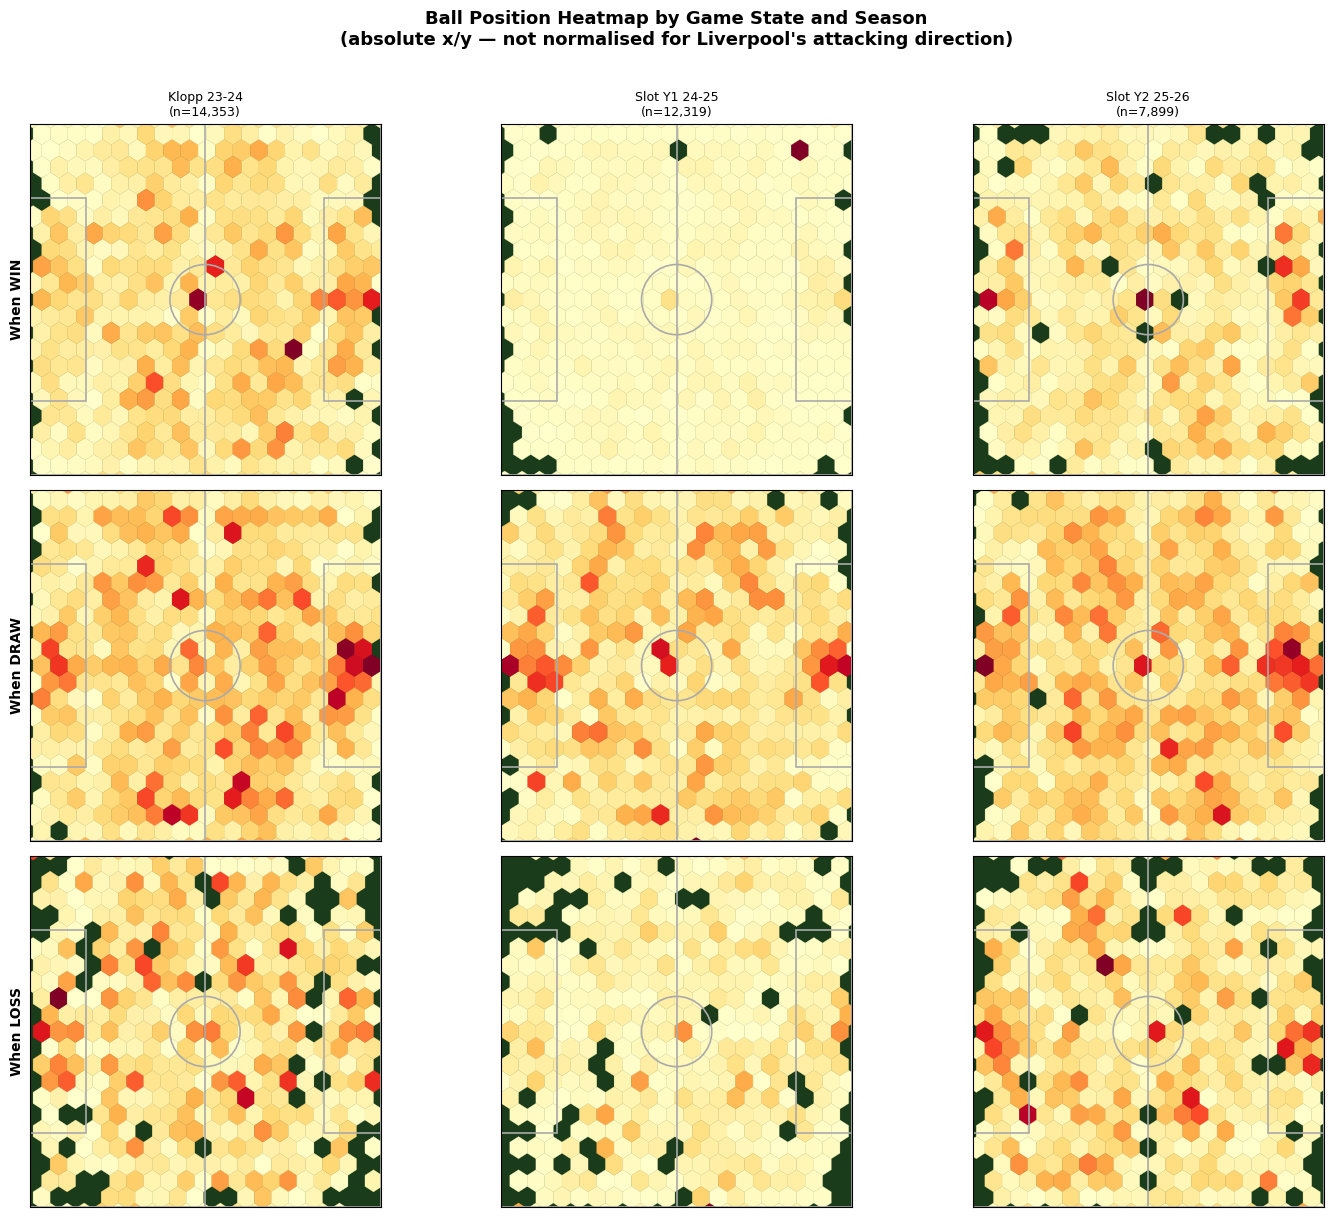

In [16]:
# Pitch heatmap: ball (x, y) distribution by game state and season
# Uses 2D hexbin on a pitch rectangle outline.
# Caveat: x-axis is absolute (not Liverpool-direction-normalised — see Part 5 markdown).

def draw_pitch_outline(ax, color="#aaaaaa", linewidth=1.2):
    """Draw a basic pitch outline on axes where x=[0,1] and y=[0,1]."""
    from matplotlib.patches import Rectangle, Arc
    # Outer boundary
    ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, edgecolor=color, linewidth=linewidth))
    # Halfway line
    ax.axvline(0.5, color=color, linewidth=linewidth)
    # Centre circle (approximate)
    circle = plt.Circle((0.5, 0.5), 0.1, fill=False, edgecolor=color, linewidth=linewidth)
    ax.add_patch(circle)
    # Left penalty box (approx)
    ax.add_patch(Rectangle((0, 0.21), 0.16, 0.58, fill=False, edgecolor=color, linewidth=linewidth))
    # Right penalty box (approx)
    ax.add_patch(Rectangle((0.84, 0.21), 0.16, 0.58, fill=False, edgecolor=color, linewidth=linewidth))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle(
    "Ball Position Heatmap by Game State and Season\n"
    "(absolute x/y — not normalised for Liverpool's attacking direction)",
    fontsize=13, fontweight="bold", y=1.01
)

for row_idx, state in enumerate(STATE_ORDER):
    for col_idx, sid in enumerate(SEASON_IDS):
        ax = axes[row_idx][col_idx]
        sub = coords_df[(coords_df["game_state"] == state) & (coords_df["season_id"] == sid)]

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")
        ax.set_facecolor("#1a3c1a")  # grass green

        if len(sub) > 10:
            ax.hexbin(
                sub["x"], sub["y"],
                gridsize=20,
                cmap="YlOrRd",
                mincnt=1,
                linewidths=0.2,
            )
        draw_pitch_outline(ax)

        n = len(sub)
        if col_idx == 0:
            ax.set_ylabel(f"When {state}", fontsize=10, fontweight="bold")
        if row_idx == 0:
            ax.set_title(f"{SEASON_LABELS[sid]}\n(n={n:,})", fontsize=9)

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


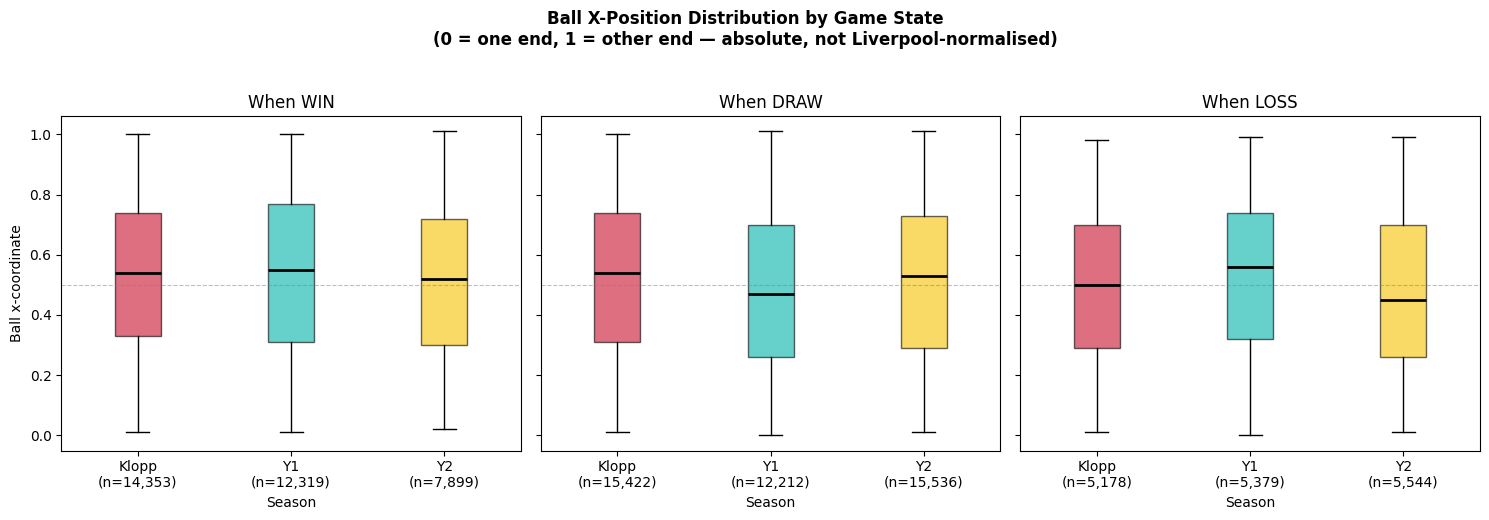

In [17]:
# X-coordinate distribution by game state and season (box plots)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Ball X-Position Distribution by Game State\n(0 = one end, 1 = other end — absolute, not Liverpool-normalised)",
             fontsize=12, fontweight="bold", y=1.03)

for ax_idx, state in enumerate(STATE_ORDER):
    ax = axes[ax_idx]
    plot_data = []
    labels = []
    actual_sids = []
    for sid in SEASON_IDS:
        sub = coords_df[(coords_df["game_state"] == state) & (coords_df["season_id"] == sid)]["x"]
        if len(sub) > 0:
            plot_data.append(sub.values)
            labels.append(f"{SEASON_SHORT[sid]}\n(n={len(sub):,})")
            actual_sids.append(sid)

    bp = ax.boxplot(plot_data, labels=labels, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, sid in zip(bp["boxes"], actual_sids):
        patch.set_facecolor(SEASON_COLORS[sid])
        patch.set_alpha(0.6)

    ax.set_title(f"When {state}")
    ax.set_xlabel("Season")
    if ax_idx == 0:
        ax.set_ylabel("Ball x-coordinate")
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

In [18]:
# Mean and IQR of x by (season, game_state)
print("Mean ball x-coordinate by season and game state:")
x_stats = (
    coords_df
    .groupby(["season_id", "game_state"])["x"]
    .agg(["mean", "std", lambda q: q.quantile(0.25), lambda q: q.quantile(0.75)])
    .reset_index()
)
x_stats.columns = ["season_id", "game_state", "mean_x", "std_x", "q25_x", "q75_x"]
x_stats["season"] = x_stats["season_id"].map(SEASON_SHORT)
x_stats["IQR"] = x_stats["q75_x"] - x_stats["q25_x"]

pivot_mean = x_stats.pivot_table(index="game_state", columns="season_id", values="mean_x").reindex(STATE_ORDER)
pivot_mean.columns = [SEASON_SHORT[c] for c in pivot_mean.columns]
pivot_iqr  = x_stats.pivot_table(index="game_state", columns="season_id", values="IQR").reindex(STATE_ORDER)
pivot_iqr.columns = [SEASON_SHORT[c] for c in pivot_iqr.columns]

print("\nMean x:")
print(pivot_mean.round(3).to_string())
print("\nIQR (spread):")
print(pivot_iqr.round(3).to_string())

# Statistical tests: aggregate to per-fixture mean first to avoid pseudoreplication.
# Raw ball-coordinate rows (~900/match) are autocorrelated — testing on them directly
# inflates N to ~10k+, making trivial differences 'significant'. Per-fixture means
# give independent observations (N = 37 / 34 / 30).
print("\n--- Statistical tests: per-fixture mean x when WINNING (avoids pseudoreplication) ---")
x_by_fixture = (
    coords_df[coords_df["game_state"] == "WIN"]
    .groupby(["season_id", "fixture_id"])["x"]
    .mean()
    .reset_index()
)

for confirmatory, sid1, sid2, label in [
    (True,  21646, 25583, "Klopp vs Y2"),
    (False, 23614, 25583, "Y1 vs Y2"),
]:
    x1 = x_by_fixture[x_by_fixture["season_id"] == sid1]["x"].values
    x2 = x_by_fixture[x_by_fixture["season_id"] == sid2]["x"].values
    if len(x1) == 0 or len(x2) == 0:
        print(f"  {label}: insufficient data")
        continue
    t, p = stats.ttest_ind(x1, x2, equal_var=False)
    d = (np.mean(x1) - np.mean(x2)) / np.sqrt(
        (np.std(x1, ddof=1)**2 + np.std(x2, ddof=1)**2) / 2
    )
    tag = "CONFIRMATORY" if confirmatory else "EXPLORATORY"
    threshold = 0.00114 if confirmatory else 0.05
    sig = ("SIGNIFICANT ✅" if (confirmatory and p < 0.00114)
           else ("directional ⚠️" if (not confirmatory and p < 0.05)
           else "no signal"))
    n1, n2 = len(x1), len(x2)
    print(f"  [{tag}] {label} (n={n1} vs n={n2}): "
          f"mean x {np.mean(x1):.3f} vs {np.mean(x2):.3f}, d={d:.2f}, p={p:.4f} → {sig}")
    print(f"    Note: d={d:.2f} is the effect size on absolute (non-directional) x. "
          f"Interpret with ball-coordinate direction caveat.")


Mean ball x-coordinate by season and game state:

Mean x:
            Klopp     Y1     Y2
game_state                     
WIN         0.527  0.534  0.514
DRAW        0.521  0.485  0.508
LOSS        0.495  0.530  0.481

IQR (spread):
            Klopp    Y1    Y2
game_state                   
WIN          0.41  0.46  0.42
DRAW         0.43  0.44  0.44
LOSS         0.41  0.42  0.44

--- Statistical tests: per-fixture mean x when WINNING (avoids pseudoreplication) ---
  [CONFIRMATORY] Klopp vs Y2 (n=28 vs n=19): mean x 0.523 vs 0.495, d=0.33, p=0.3008 → no signal
    Note: d=0.33 is the effect size on absolute (non-directional) x. Interpret with ball-coordinate direction caveat.
  [EXPLORATORY] Y1 vs Y2 (n=28 vs n=19): mean x 0.517 vs 0.495, d=0.23, p=0.4579 → no signal
    Note: d=0.23 is the effect size on absolute (non-directional) x. Interpret with ball-coordinate direction caveat.


---
### Part 6 — Goals Timing: When in the Match Do Liverpool Score and Concede?

Break goals into 15-minute bins to find when Liverpool are most dangerous and most vulnerable.

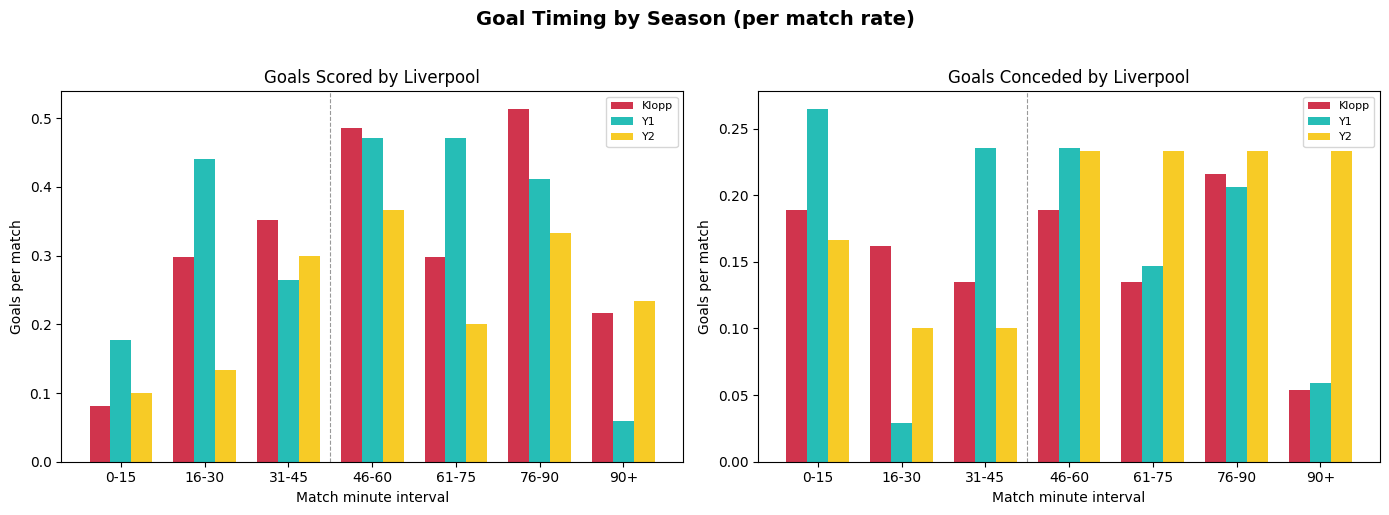

In [19]:
# Bin goals into 15-minute intervals
bins = [0, 15, 30, 45, 60, 75, 90, 120]  # 120 to catch late ET goals
labels_bins = ["0-15", "16-30", "31-45", "46-60", "61-75", "76-90", "90+"]

goals_by_state_df["minute_bin"] = pd.cut(
    goals_by_state_df["minute"], bins=bins, labels=labels_bins, right=True
)

# Per-match goal rate by time bin and season
n_fixtures_per_season = trans_df.groupby("season_id")["fixture_id"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Goal Timing by Season (per match rate)", fontsize=14, fontweight="bold", y=1.02)

for ax_idx, (scorer_type, title) in enumerate([
    ("liverpool", "Goals Scored by Liverpool"),
    ("opponent",  "Goals Conceded by Liverpool"),
]):
    ax = axes[ax_idx]
    sub = goals_by_state_df[goals_by_state_df["scorer"] == scorer_type]

    x = np.arange(len(labels_bins))
    width = 0.25

    for i, sid in enumerate(SEASON_IDS):
        n = n_fixtures_per_season.get(sid, 1)
        counts = sub[sub["season_id"] == sid]["minute_bin"].value_counts().reindex(labels_bins, fill_value=0)
        vals = (counts / n).values
        ax.bar(x + (i - 1) * width, vals, width,
               color=SEASON_COLORS[sid], alpha=0.85, label=SEASON_SHORT[sid])

    ax.set_xticks(x)
    ax.set_xticklabels(labels_bins)
    ax.set_xlabel("Match minute interval")
    ax.set_ylabel("Goals per match")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.axvline(2.5, color="black", linestyle="--", linewidth=0.8, alpha=0.4, label="Half-time")

plt.tight_layout()
plt.show()

---
### Summary of Findings

**Dataset**: 101 fixtures — Klopp=37, Slot Y1=34, Slot Y2=30 (partial season)

#### Match outcomes
| Season | W | D | L | GF | GA | GD | PPG |
|--------|---|---|---|----|----|----|-----|
| Klopp 23-24 | 23 | 10 | 4 | 83 | 40 | +43 | 2.14 |
| Slot Y1 24-25 | 21 | 9 | 4 | 78 | 40 | +38 | 2.12 |
| Slot Y2 25-26 | 14 | 7 | 9 | 50 | 39 | +11 | 1.63 |

#### Time in each game state (avg % per match)
- **Klopp**: WIN=35.9%, DRAW=47.9%, LOSS=16.2%
- **Slot Y1**: WIN=41.0%, DRAW=41.3%, LOSS=17.7% — Y1 spent *more* time winning than any season
- **Slot Y2**: WIN=28.0%, DRAW=52.5%, LOSS=19.5% — Y2 is the outlier: far less time ahead, more time level

#### Lead management
- Y2 leads in only **63% of games** vs 82% (Y1) and 76% (Klopp)
- When Y2 do lead: they win the match in **47%** of all games — down from 62% (Klopp/Y1)
- Lead temporarily blown (any concession while ahead): Y2=23% of games vs Y1=32%, Klopp=30% — Y2 slightly *better* at holding leads once taken
- **The regression is driven by taking the lead less often, not by conceding more when ahead**

#### Goals — the deadlock problem
- Goals scored from DRAW state per match: Klopp=0.97, Y1=0.97, **Y2=0.73** — 25% fewer go-ahead goals
- Goals scored when already winning: Klopp=0.86, Y1=0.79, **Y2=0.53** — Y2 also struggle to extend leads
- Goals conceded from WIN state: consistent ~0.51–0.53/match across all seasons — not a blowing-leads problem

#### Ball territory when winning (corrected analysis)
- Y2 attacking_third occupancy when winning: **32.7%** vs Y1 36.9% and Klopp 34.5% — Y2 sits deeper
- Per-fixture mean x test (Klopp vs Y2): d=0.33, p=0.30 — **not statistically significant** at any threshold
- The zone percentage shift is descriptive; causal interpretation requires possession-tagged coordinates
- **Caveat**: ball x/y not normalised for Liverpool's attacking direction — treat as aggregate signal only

#### Key narrative for the thread
> *Y2 Liverpool aren't blowing leads — they're taking them 25% less often per match.*  
> *Y1 was the dominant season: 41% of match time spent winning, 82% of games with Liverpool ahead at some point.*  
> *Y2's collapse is in the deadlock moments: when it's level, Slot's Liverpool can't find the breakthrough goal.*


In [20]:
# --- Findings summary (auto-generated) ---
print("=" * 70)
print("DEEP DIVE 1.4 — KEY FINDINGS SUMMARY")
print("=" * 70)

print("\n[MATCH OUTCOMES]")
print(summary_df[["Season", "W", "D", "L", "GF", "GA", "GD", "PPG"]].to_string(index=False))

print("\n[TIME IN EACH GAME STATE — avg % per match]")
for sid in SEASON_IDS:
    sub = trans_df[trans_df["season_id"] == sid]
    print(f"  {SEASON_SHORT[sid]}: WIN={sub['pct_win'].mean():.1%}  DRAW={sub['pct_draw'].mean():.1%}  LOSS={sub['pct_loss'].mean():.1%}")

print("\n[LEAD MANAGEMENT — % of matches where Liverpool led]")
for sid in SEASON_IDS:
    sub = trans_df[trans_df["season_id"] == sid]
    ever_led = sub[sub["ever_led"]]
    if len(ever_led) == 0:
        continue
    held_pct = ever_led["lead_held"].mean()
    blown_pct = ever_led["lead_blown"].mean()
    print(f"  {SEASON_SHORT[sid]}: Led in {sub['ever_led'].mean():.0%} of games. Of those: held={held_pct:.0%}, blown={blown_pct:.0%}")

print("\n[GOALS CONCEDED FROM WIN STATE — 'blowing leads' — per match]")
for sid in SEASON_IDS:
    n = n_fixtures_per_season.get(sid, 1)
    blown = goals_by_state_df[
        (goals_by_state_df["season_id"] == sid) &
        (goals_by_state_df["scorer"] == "opponent") &
        (goals_by_state_df["state_before"] == "WIN")
    ].shape[0]
    print(f"  {SEASON_SHORT[sid]}: {blown} goals conceded from WIN state ({blown / n:.2f}/match)")

DEEP DIVE 1.4 — KEY FINDINGS SUMMARY

[MATCH OUTCOMES]
       Season  W  D  L  GF  GA  GD  PPG
  Klopp 23-24 23 10  4  83  40  43 2.14
Slot Y1 24-25 21  9  4  78  40  38 2.12
Slot Y2 25-26 14  7  9  50  39  11 1.63

[TIME IN EACH GAME STATE — avg % per match]
  Klopp: WIN=36.2%  DRAW=47.6%  LOSS=16.2%
  Y1: WIN=41.1%  DRAW=41.2%  LOSS=17.6%
  Y2: WIN=28.2%  DRAW=52.2%  LOSS=19.5%

[LEAD MANAGEMENT — % of matches where Liverpool led]
  Klopp: Led in 76% of games. Of those: held=82%, blown=39%
  Y1: Led in 82% of games. Of those: held=75%, blown=39%
  Y2: Led in 63% of games. Of those: held=74%, blown=37%

[GOALS CONCEDED FROM WIN STATE — 'blowing leads' — per match]
  Klopp: 19 goals conceded from WIN state (0.51/match)
  Y1: 17 goals conceded from WIN state (0.50/match)
  Y2: 16 goals conceded from WIN state (0.53/match)
